In [3]:
import os
import numpy as np  
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from stargazer.stargazer import Stargazer

In [12]:

df_path = os.path.join("..", "data", "combined.csv")   # ../data/combined.csv from src/
assert os.path.exists(df_path), f"File not found: {df_path}"
df = pd.read_csv(df_path)
df.head(6)

,ResponseId,Age,Gender,shopping_freq,limi_prod_imp,cookie,cup,sneakers,headphones,perfume,treated
0,R_3TJYd3ZkDqxNCsF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,R_1KYAQ68yuP1nbc5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,R_3LcEQ68CnM5EaxJ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,R_3nGTNhqlvMXRZP0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,R_1npfqTJcetbP2qO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0
5,R_3QzGsqB61jrxU0F,2.0,NaN,1.0,2.0,62.0,69.0,62.0,62.0,49.0,0


In [14]:
df = df.dropna()
df = df[df[['cookie','sneakers']].notna().all(axis=1)]

In [16]:
df['Treatment_factor'] = df['treated'].map({0: 'Control', 1: 'Treatment'})
df

,ResponseId,Age,Gender,shopping_freq,limi_prod_imp,cookie,cup,sneakers,headphones,perfume,treated,Treatment_factor
7,R_32aGTQyahiqOmQP,2.0,4.0,3.0,2.0,65.0,68.0,50.0,69.0,30.0,0,Control
8,R_3jNdu3373Leb3vN,1.0,2.0,2.0,1.0,21.0,16.0,27.0,34.0,32.0,0,Control
9,R_39H3cBYvGCmraQ9,4.0,2.0,2.0,5.0,31.0,30.0,27.0,37.0,43.0,0,Control
10,R_3whQcOKLKrRChcL,2.0,1.0,3.0,3.0,10.0,50.0,80.0,70.0,80.0,1,Treatment
11,R_3gI5E345rXqI8cZ,3.0,1.0,2.0,4.0,92.0,11.0,85.0,83.0,61.0,1,Treatment
12,R_3kS8gRyuwG6jqVY,4.0,2.0,2.0,3.0,49.0,33.0,46.0,55.0,56.0,1,Treatment
13,R_3EYjSGulk8I3uce,4.0,2.0,3.0,2.0,57.0,49.0,50.0,50.0,31.0,1,Treatment
14,R_3jZoMVhezxtNxmW,5.0,1.0,2.0,5.0,28.0,60.0,100.0,100.0,64.0,1,Treatment
15,R_3KNJTC3O6oJRTFv,3.0,2.0,2.0,4.0,28.0,21.0,87.0,83.0,82.0,1,Treatment


# ATE Without regression

In [18]:
# ...existing code...
exp_cols = ['cookie','cup','sneakers','headphones','perfume']

# ensure using the notebook dataframe variable (df)
results = {}
for col in exp_cols:
    if col not in df.columns:
        results[col] = {"error": "missing"}
        continue

    # convert to numeric where appropriate
    series = pd.to_numeric(df[col], errors='coerce')

    mean_ctr = series[df['treated'] == 0].mean()
    mean_trt = series[df['treated'] == 1].mean()
    n_ctr = series[df['treated'] == 0].notna().sum()
    n_trt = series[df['treated'] == 1].notna().sum()
    diff = mean_trt - mean_ctr

    results[col] = {
        "mean_control": mean_ctr,
        "mean_treatment": mean_trt,
        "diff": diff,
        "n_control": int(n_ctr),
        "n_treatment": int(n_trt)
    }

# keep results in a variable and print
exp_results = results
exp_results

{'cookie': {'mean_control': np.float64(39.0),
  'mean_treatment': np.float64(44.0),
  'diff': np.float64(5.0),
  'n_control': 3,
  'n_treatment': 6},
 'cup': {'mean_control': np.float64(38.0),
  'mean_treatment': np.float64(37.333333333333336),
  'diff': np.float64(-0.6666666666666643),
  'n_control': 3,
  'n_treatment': 6},
 'sneakers': {'mean_control': np.float64(34.666666666666664),
  'mean_treatment': np.float64(74.66666666666667),
  'diff': np.float64(40.00000000000001),
  'n_control': 3,
  'n_treatment': 6},
 'headphones': {'mean_control': np.float64(46.666666666666664),
  'mean_treatment': np.float64(73.5),
  'diff': np.float64(26.833333333333336),
  'n_control': 3,
  'n_treatment': 6},
 'perfume': {'mean_control': np.float64(35.0),
  'mean_treatment': np.float64(62.333333333333336),
  'diff': np.float64(27.333333333333336),
  'n_control': 3,
  'n_treatment': 6}}

# Estimating the ATE with regression


## with only treatment as one covariate


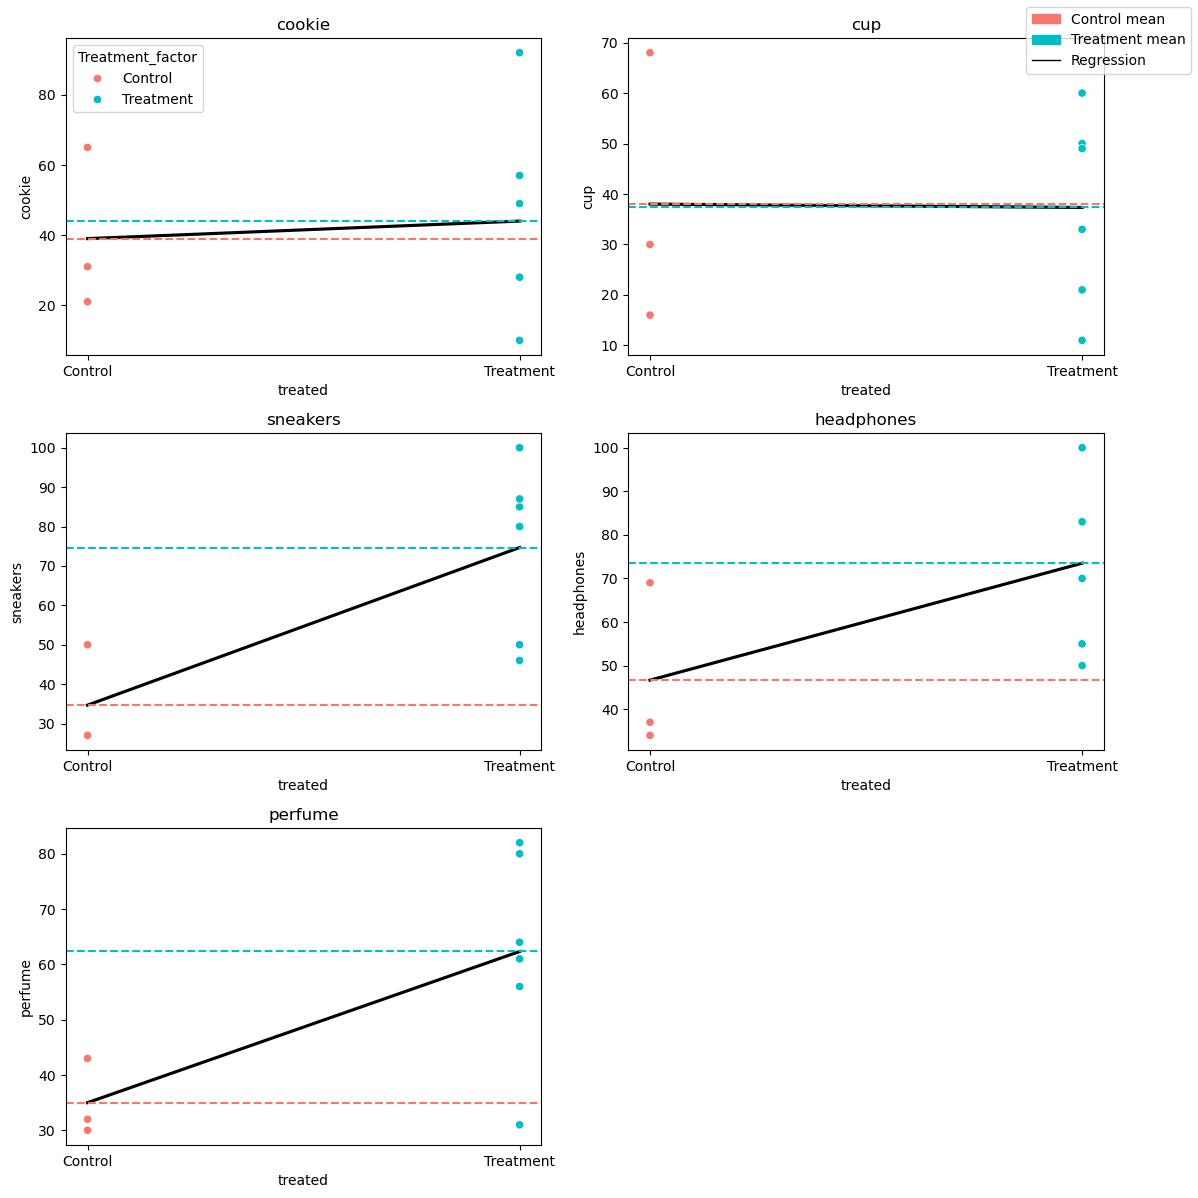

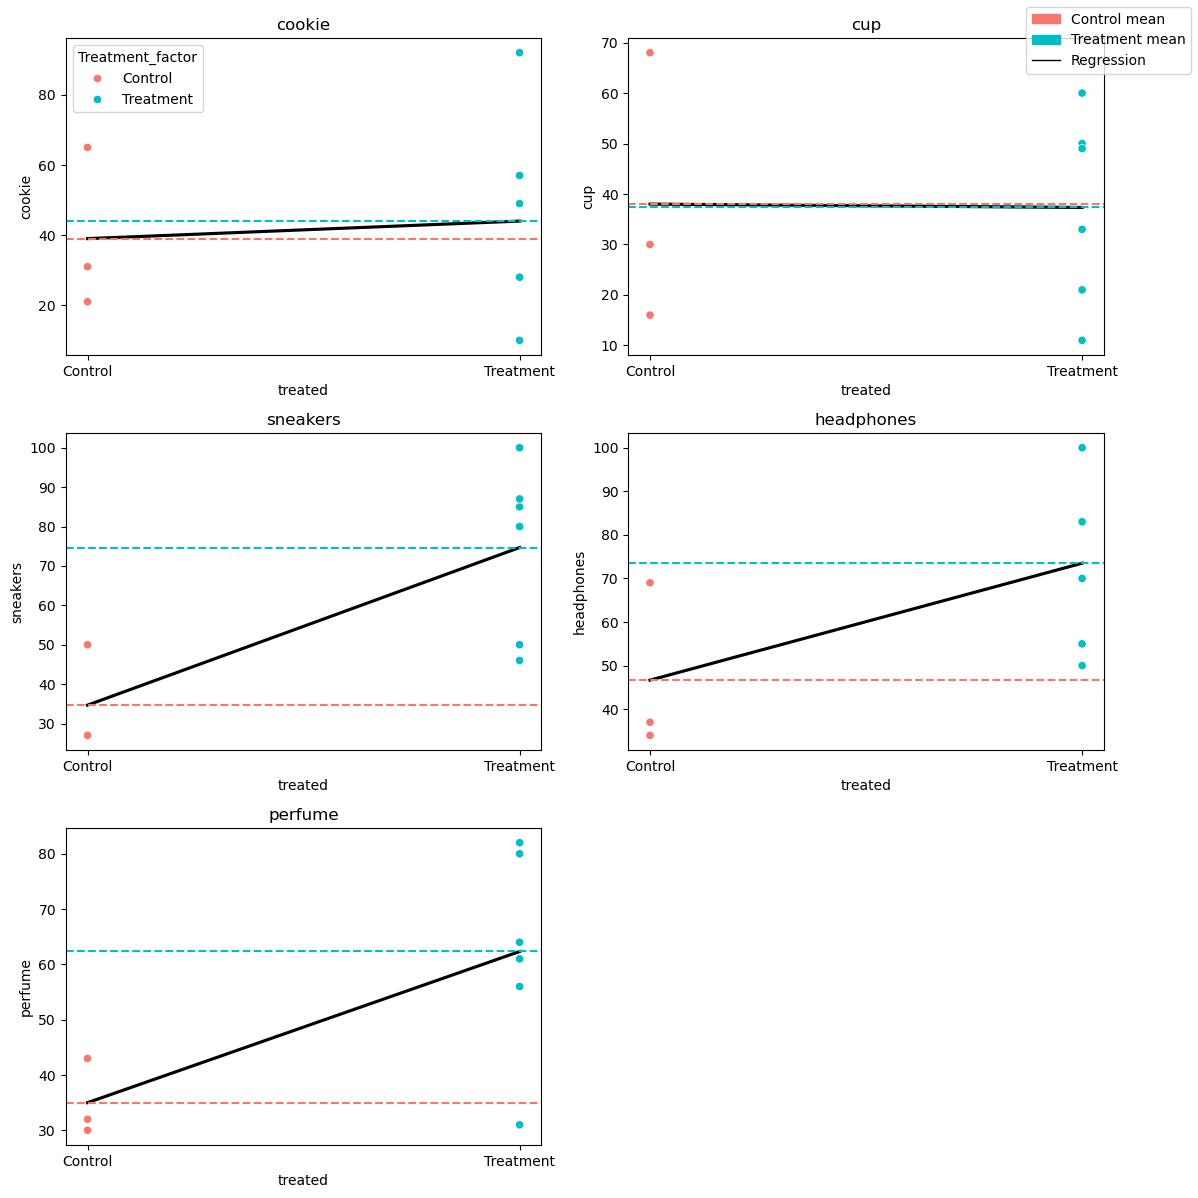

In [20]:
# Replace plotting cell with this code (plots one panel per column)
import math
import matplotlib.patches as mpatches

exp_cols = ['cookie','cup','sneakers','headphones','perfume']
cols_present = [c for c in exp_cols if c in df.columns]
if len(cols_present) == 0:
    raise RuntimeError("None of the expected experiment columns found in df.")

# ensure Treatment_factor exists
if 'Treatment_factor' not in df.columns:
    df['Treatment_factor'] = df['treated'].map({0: 'Control', 1: 'Treatment'})

n = len(cols_present)
ncols = 2
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

custom_palette = {'Control': '#F8776D', 'Treatment': '#00BFC4'}

for i, col in enumerate(cols_present):
    ax = axes[i // ncols][i % ncols]
    # numeric series for plotting/stats
    series = pd.to_numeric(df[col], errors='coerce')

    mean_ctr = series[df['treated'] == 0].mean()
    mean_trt = series[df['treated'] == 1].mean()

    # scatterplot (show legend only on first plot)
    show_legend = (i == 0)
    sns.scatterplot(data=df, x='treated', y=col, hue='Treatment_factor',
                    palette=custom_palette, ax=ax, legend=show_legend)

    # regression line
    sns.regplot(data=df, x='treated', y=col, scatter=False, color='black',
                label='Regression', ci=None, ax=ax)

    # mean lines
    ax.axhline(mean_ctr, linestyle='--', color=custom_palette['Control'], label='Mean Control' if show_legend else "")
    ax.axhline(mean_trt, linestyle='--', color=custom_palette['Treatment'], label='Mean Treatment' if show_legend else "")

    ax.set_title(col)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Control', 'Treatment'])

# remove unused subplots
total_plots = nrows * ncols
for j in range(n, total_plots):
    ax = axes[j // ncols][j % ncols]
    ax.axis('off')

# if legend suppressed on other plots, create a single legend
handles = [
    mpatches.Patch(color=custom_palette['Control'], label='Control mean'),
    mpatches.Patch(color=custom_palette['Treatment'], label='Treatment mean'),
]
# add regression line handle
handles.append(plt.Line2D([0], [0], color='black', lw=1, label='Regression'))
fig.legend(handles=handles, loc='upper right')

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

import math
import matplotlib.patches as mpatches

exp_cols = ['cookie','cup','sneakers','headphones','perfume']
cols_present = [c for c in exp_cols if c in df.columns]
if len(cols_present) == 0:
    raise RuntimeError("None of the expected experiment columns found in df.")

# ensure Treatment_factor exists
if 'Treatment_factor' not in df.columns:
    df['Treatment_factor'] = df['treated'].map({0: 'Control', 1: 'Treatment'})

n = len(cols_present)
ncols = 2
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

custom_palette = {'Control': '#F8776D', 'Treatment': '#00BFC4'}

for i, col in enumerate(cols_present):
    ax = axes[i // ncols][i % ncols]
    # numeric series for plotting/stats
    series = pd.to_numeric(df[col], errors='coerce')

    mean_ctr = series[df['treated'] == 0].mean()
    mean_trt = series[df['treated'] == 1].mean()

    # scatterplot (show legend only on first plot)
    show_legend = (i == 0)
    sns.scatterplot(data=df, x='treated', y=col, hue='Treatment_factor',
                    palette=custom_palette, ax=ax, legend=show_legend)

    # regression line
    sns.regplot(data=df, x='treated', y=col, scatter=False, color='black',
                label='Regression', ci=None, ax=ax)

    # mean lines
    ax.axhline(mean_ctr, linestyle='--', color=custom_palette['Control'], label='Mean Control' if show_legend else "")
    ax.axhline(mean_trt, linestyle='--', color=custom_palette['Treatment'], label='Mean Treatment' if show_legend else "")

    ax.set_title(col)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Control', 'Treatment'])

# remove unused subplots
total_plots = nrows * ncols
for j in range(n, total_plots):
    ax = axes[j // ncols][j % ncols]
    ax.axis('off')

# if legend suppressed on other plots, create a single legend
handles = [
    mpatches.Patch(color=custom_palette['Control'], label='Control mean'),
    mpatches.Patch(color=custom_palette['Treatment'], label='Treatment mean'),
]
# add regression line handle
handles.append(plt.Line2D([0], [0], color='black', lw=1, label='Regression'))
fig.legend(handles=handles, loc='upper right')

plt.tight_layout(rect=[0, 0, 0.95, 1])

In [53]:
reg_results = {}
for col in exp_cols:
    lm = smf.ols(formula=f'{col} ~ treated', data=df)
    fit = lm.fit(cov_type='HC1')
    reg_results[col] = fit


In [54]:
reg_results['cookie'].summary()

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 cookie   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.132
Method:                 Least Squares   F-statistic:                   0.08312
Date:                Tue, 17 Feb 2026   Prob (F-statistic):              0.781
Time:                        12:29:38   Log-Likelihood:                -41.413
No. Observations:                   9   AIC:                             86.83
Df Residuals:                       7   BIC:                             87.22
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.0000     12.329      3.163      0.002      14.836      63.164
treated        5.0000     17.343      0.288      0.773     -28.992      38.992
==============================================================================
Omnibus:                        1.145   Durbin-Watson:                   2.331
Prob(Omnibus):                  0.564   Jarque-Bera (JB):                0.678
Skew:                           0.608   Prob(JB):                        0.712
Kurtosis:                       2.425   Cond. No.                         3.23
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [55]:

reg_results['cup'].summary()

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cup   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.143
Method:                 Least Squares   F-statistic:                  0.001641
Date:                Tue, 17 Feb 2026   Prob (F-statistic):              0.969
Time:                        12:30:02   Log-Likelihood:                -39.254
No. Observations:                   9   AIC:                             82.51
Df Residuals:                       7   BIC:                             82.90
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     38.0000     14.383      2.642      0.008       9.811      66.189
treated       -0.6667     16.455     -0.041      0.968     -32.918      31.584
==============================================================================
Omnibus:                        1.493   Durbin-Watson:                   2.233
Prob(Omnibus):                  0.474   Jarque-Bera (JB):                0.722
Skew:                           0.137   Prob(JB):                        0.697
Kurtosis:                       1.639   Cond. No.                         3.23
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

'sneakers','headphones','perfume'

In [56]:
reg_results['headphones'].summary()

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             headphones   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     4.200
Date:                Tue, 17 Feb 2026   Prob (F-statistic):             0.0796
Time:                        12:30:42   Log-Likelihood:                -38.166
No. Observations:                   9   AIC:                             80.33
Df Residuals:                       7   BIC:                             80.73
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     46.6667     10.369      4.500      0.000      26.343      66.990
treated       26.8333     13.093      2.049      0.040       1.171      52.496
==============================================================================
Omnibus:                        1.301   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.522   Jarque-Bera (JB):                0.711
Skew:                           0.215   Prob(JB):                        0.701
Kurtosis:                       1.692   Cond. No.                         3.23
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [57]:
reg_results['sneakers'].summary()

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               sneakers   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     11.88
Date:                Tue, 17 Feb 2026   Prob (F-statistic):             0.0107
Time:                        12:31:05   Log-Likelihood:                -38.457
No. Observations:                   9   AIC:                             80.91
Df Residuals:                       7   BIC:                             81.31
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.6667      7.098      4.884      0.000      20.755      48.578
treated       40.0000     11.604      3.447      0.001      17.257      62.743
==============================================================================
Omnibus:                        0.776   Durbin-Watson:                   1.817
Prob(Omnibus):                  0.679   Jarque-Bera (JB):                0.635
Skew:                          -0.350   Prob(JB):                        0.728
Kurtosis:                       1.903   Cond. No.                         3.23
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [58]:
reg_results['perfume'].summary()

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                perfume   R-squared:                       0.450
Model:                            OLS   Adj. R-squared:                  0.372
Method:                 Least Squares   F-statistic:                     9.880
Date:                Tue, 17 Feb 2026   Prob (F-statistic):             0.0163
Time:                        12:31:22   Log-Likelihood:                -36.671
No. Observations:                   9   AIC:                             77.34
Df Residuals:                       7   BIC:                             77.74
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     35.0000      3.742      9.354      0.000      27.666      42.334
treated       27.3333      8.696      3.143      0.002      10.290      44.377
==============================================================================
Omnibus:                        2.867   Durbin-Watson:                   1.449
Prob(Omnibus):                  0.239   Jarque-Bera (JB):                0.717
Skew:                          -0.676   Prob(JB):                        0.699
Kurtosis:                       3.295   Cond. No.                         3.23
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

## Regression with multiple features    
i.e.   Age	Gender	shopping_freq	limi_prod_imp	


=== cookie ~ treatment + covariates (n=9) ===


=== cookie ~ treatment + covariates (n=9) ===

                   coef  p-value
Intercept      398.0000      NaN
C(Age)[T.2.0]  340.6667      NaN
C(Age)[T.3.0]  430.6667      NaN
C(Age)[T.4.0]  363.3333      NaN
C(Age)[T.5.0]  455.0000      NaN
treated       -158.6667      NaN
Gender         -64.0000      NaN
shopping_freq  -80.3333      NaN
limi_prod_imp  -88.3333      NaN
R²: 1.0000

=== cup ~ treatment + covariates (n=9) ===


=== cup ~ treatment + covariates (n=9) ===

               coef  p-value
Intercept     -45.0      1.0
C(Age)[T.2.0]  10.0      1.0
C(Age)[T.3.0] -13.0      1.0
C(Age)[T.4.0]   2.0      1.0
C(Age)[T.5.0]  33.0      1.0
treated         9.0      1.0
Gender         10.0      1.0
shopping_freq  19.0      1.0
limi_prod_imp   3.0      1.0
R²: 1.0000

=== sneakers ~ treatment + covariates (n=9) ===


=== sneakers ~ treatment + covariates (n=9) ===

                  coef  p-value
Intercept      -2.0000      1.0
C(Age)[T

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: invalid value encountered in multiply
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_sc

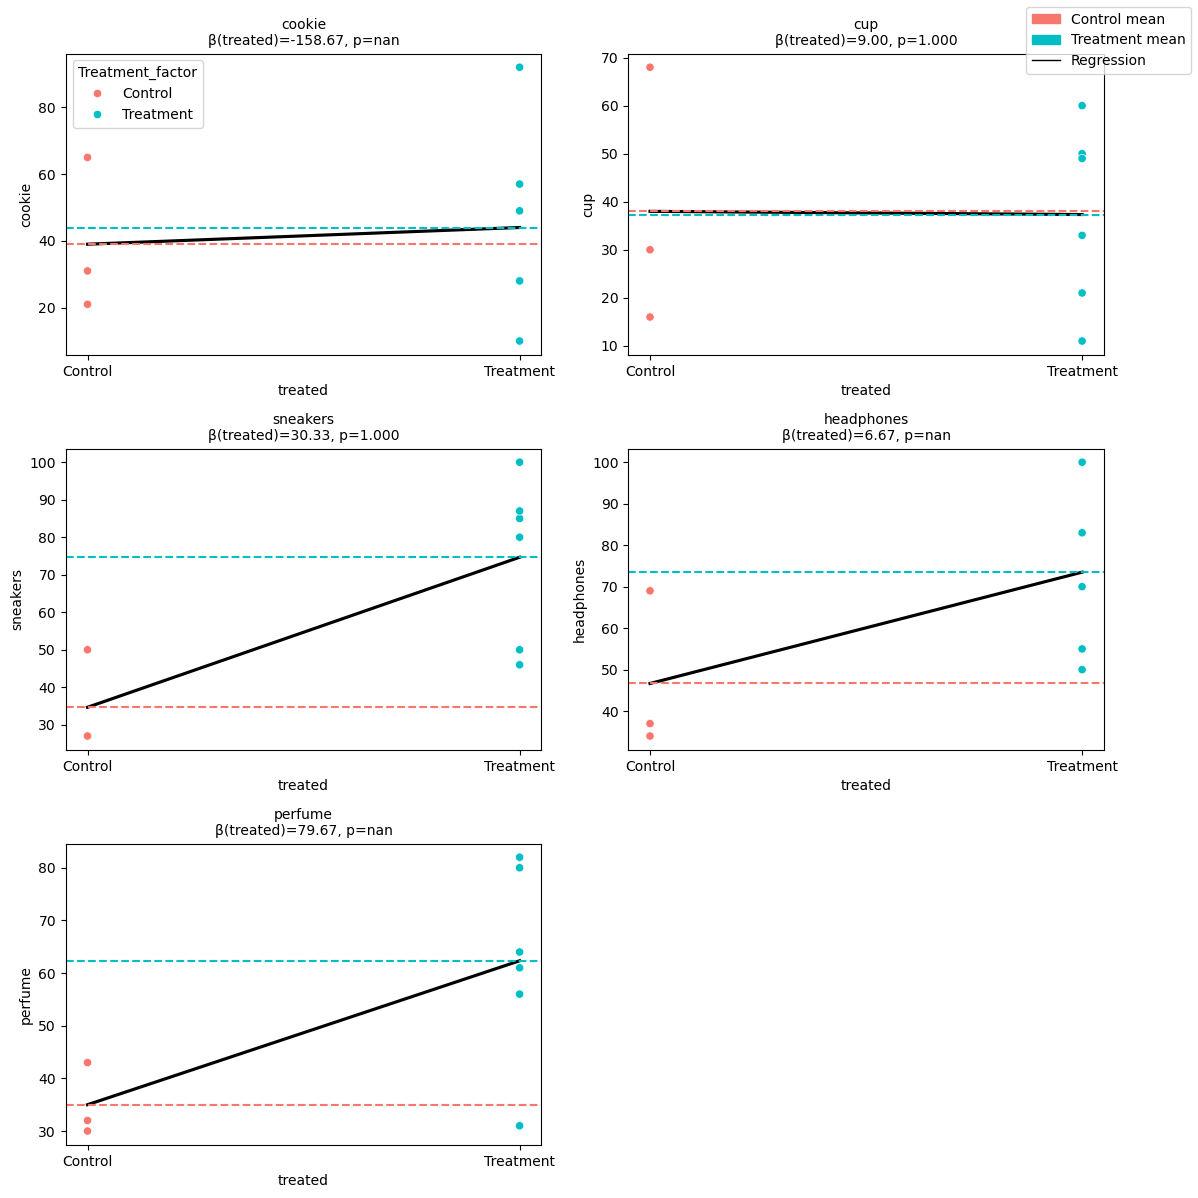

In [62]:
import math
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf

exp_cols = ['cookie', 'cup', 'sneakers', 'headphones', 'perfume']
covariates = ['Age', 'Gender', 'shopping_freq', 'limi_prod_imp']
cols_present = [c for c in exp_cols if c in df.columns]

if len(cols_present) == 0:
    raise RuntimeError("None of the expected experiment columns found in df.")

# Treat Age as categorical (ordinal ranges 1-4), others as continuous
df['Age'] = df['Age'].astype('category')

if 'Treatment_factor' not in df.columns:
    df['Treatment_factor'] = df['treated'].map({0: 'Control', 1: 'Treatment'})

# --- Regressions with covariates ---
reg_results = {}
covariate_formula = 'treated + C(Age) + Gender + shopping_freq + limi_prod_imp'

for col in cols_present:
    df_reg = df[[col, 'treated', 'Age', 'Gender', 'shopping_freq', 'limi_prod_imp']].copy()
    for c in [col, 'treated', 'Gender', 'shopping_freq', 'limi_prod_imp']:
        df_reg[c] = pd.to_numeric(df_reg[c], errors='coerce')
    df_reg = df_reg.dropna()

    lm = smf.ols(formula=f'{col} ~ {covariate_formula}', data=df_reg)
    fit = lm.fit(cov_type='HC1')
    reg_results[col] = fit

    print(f"\n=== {col} ~ treatment + covariates (n={df_reg.shape[0]}) ===\n")
    print(f"\n=== {col} ~ treatment + covariates (n={df_reg.shape[0]}) ===\n")
    print(fit.params.to_frame('coef').join(fit.pvalues.to_frame('p-value')).round(4))
    print(f"R²: {fit.rsquared:.4f}")

# --- Plots (partial regression / raw scatter with regression line) ---
n = len(cols_present)
ncols = 2
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

custom_palette = {'Control': '#F8776D', 'Treatment': '#00BFC4'}

for i, col in enumerate(cols_present):
    ax = axes[i // ncols][i % ncols]
    series = pd.to_numeric(df[col], errors='coerce')

    mean_ctr = series[df['treated'] == 0].mean()
    mean_trt = series[df['treated'] == 1].mean()

    show_legend = (i == 0)
    sns.scatterplot(data=df, x='treated', y=col, hue='Treatment_factor',
                    palette=custom_palette, ax=ax, legend=show_legend)
    sns.regplot(data=df, x='treated', y=col, scatter=False, color='black',
                ci=None, ax=ax)

    ax.axhline(mean_ctr, linestyle='--', color=custom_palette['Control'])
    ax.axhline(mean_trt, linestyle='--', color=custom_palette['Treatment'])

    # Annotate treatment coefficient and p-value from the covariate model
    coef = reg_results[col].params['treated']
    pval = reg_results[col].pvalues['treated']
    ax.set_title(f"{col}\nβ(treated)={coef:.2f}, p={pval:.3f}", fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Control', 'Treatment'])

# Remove unused subplots
for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

handles = [
    mpatches.Patch(color=custom_palette['Control'], label='Control mean'),
    mpatches.Patch(color=custom_palette['Treatment'], label='Treatment mean'),
    plt.Line2D([0], [0], color='black', lw=1, label='Regression'),
]
fig.legend(handles=handles, loc='upper right')
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()